# FOOD PRICE STABILITY PREDICTIVE ANALYTICS

---



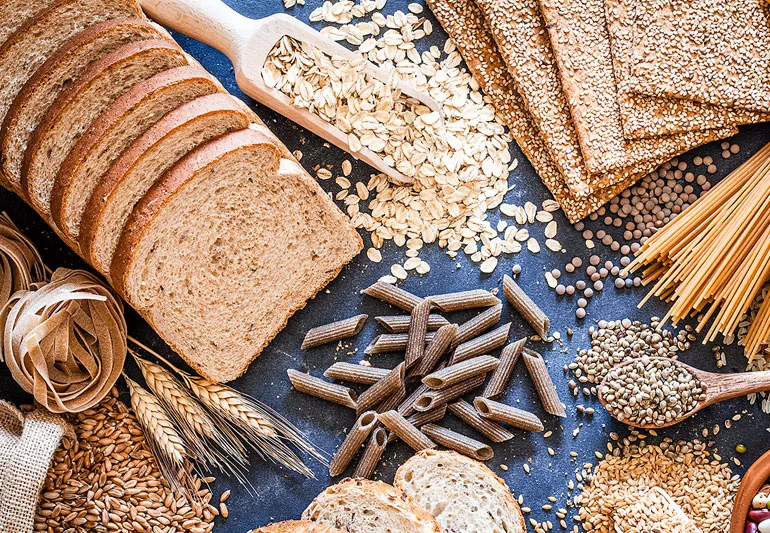

## PROJECT OVERVIEW

---



Food pricing is one of the key factors that determine access to food. An increase in food prices reduces the purchasing power and therefore limits the quantity of food that can be purchased. The food inflation rate has more than doubled in the past year to 13.8% as of June 2022 from 6.32% in June 2021.Some of the items in the food basket driving food inflation include wheat, cooking oil, maize flour, milk, potatoes, onion and carrot. The highest average price change is recorded for maize flour at 67% Kenyans through social media campaigns have been pressuring the government into taking specific actions on food prices.These unpredictable fluctuations create a destabilizing cycle for both consumers and producers, as the market rapidly oscillates between wasteful surpluses and acute shortages.  


This project seeks to mitigate these imbalances by utilizing time-series forecasting to provide reliable price predictions. By delivering actionable insights such as forecasting the value of a 90kg bag of maize half a year into the future the model empowers farmers in regions like Uasin Gishu to make informed, data-driven decisions on whether to maintain current crop cycles or pivot to more viable alternatives.  

## Business Understanding

The agricultural sector plays a major role in Kenya’s economy and food supply. However, unstable food prices create uncertainty for farmers, consumers, businesses, and government agencies.

Many stakeholders currently rely on traditional experience and manual estimation methods instead of predictive systems. This limits their ability to prepare for shortages, inflation, or surplus production.

The purpose of this project is to provide predictive insights that support better planning and reduce the negative impact of food price volatility.

## Problem Description

Food prices in Kenya often fluctuate due to changing weather conditions, fuel price changes, transportation costs, and seasonal farming cycles. These fluctuations can lead to:

- High food costs for consumers
- Losses for farmers during surplus seasons
- Poor planning and budgeting
- Food insecurity in vulnerable regions

Currently, there are limited intelligent systems that use historical and external data to forecast food prices accurately.

This project aims to solve this problem by building a machine learning-based predictive system capable of forecasting future prices of key food commodities.

## Project Objectives

### Primary Objective
To develop a predictive analytics model that forecasts the prices of key food commodities in Kenya, including maize, milk, and beans.

### Secondary Objectives
- Analyze historical food price trends
- Study the effect of rainfall on food prices
- Study the impact of fuel prices on transportation and food costs
- Improve prediction accuracy using external variables
- Develop an interactive Streamlit dashboard for visualization and forecasting

## Why the Project Matters

Food price instability directly affects economic stability, household budgeting, and agricultural planning in Kenya.

This project is important because it can:
- Help farmers make better planting and selling decisions
- Help consumers prepare for future price changes
- Support government policy and food security planning
- Reduce losses caused by poor market timing
- Encourage data-driven agricultural decision-making

## Stakeholders

### Consumers
Consumers can use the predictions for budgeting and planning household expenses.

### Farmers and Agricultural Saccos
Farmers can use predicted prices to decide when to plant, harvest, store, or sell their produce.

### Government Agencies
Organizations such as the Ministry of Agriculture and NCPB can use the system for food security monitoring and policy planning.

### Insurance Providers
Insurance companies can use predictive insights for agricultural risk assessment and pricing strategies.

## Expected Outcomes

The project is expected to produce:
- Accurate food price prediction models
- Identification of seasonal price patterns
- Insights into how rainfall and fuel prices affect food prices
- Interactive dashboards and visualizations
- Early warning indicators for possible price spikes
- A deployed Streamlit web application for users

## Potential Impact

The system has the potential to improve decision-making across the agricultural supply chain.

Potential impacts include:
- Improved farm productivity and planning
- Better consumer financial planning
- Reduced market inefficiencies
- Increased food security awareness
- Enhanced use of data analytics in agriculture

## Key Deliverables

The project deliverables include:

1. Cleaned and merged datasets
2. Exploratory Data Analysis (EDA)
3. Feature engineering and preprocessing pipeline
4. Machine learning prediction models
5. Model evaluation results using MAE and RMSE
6. Data visualizations and trend analysis
7. Streamlit web application
8. Final project report and presentation

## Data Understanding

### Import Libraries

The project begins by importing the necessary Python libraries for data analysis, visualization, preprocessing, and machine learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### Load Datasets

The datasets are loaded into pandas DataFrames for analysis and preprocessing.

The project uses:
- Food prices dataset
- Rainfall dataset
- Fuel prices dataset

In [32]:
food = pd.read_csv("data/wfp_food_prices_ken.csv")

rainfall= pd.read_csv("data/ken-rainfall-subnat-full.csv")

fuel = pd.read_csv("data/Pump Prices Energy and Petroleum Regulatory Authority.csv")

## Create Dataset Copies

Copies of the original datasets are created to avoid modifying the raw data directly.

In [33]:
food_df = food.copy()

rainfall_df = rainfall.copy()

fuel_df = fuel.copy()

#### Preview the Datasets

The first few rows are displayed to understand the structure and contents of each dataset.

In [34]:
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19005 entries, 0 to 19004
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          19005 non-null  object 
 1   admin1        18966 non-null  object 
 2   admin2        18966 non-null  object 
 3   market        19005 non-null  object 
 4   market_id     19005 non-null  int64  
 5   latitude      18966 non-null  float64
 6   longitude     18966 non-null  float64
 7   category      19005 non-null  object 
 8   commodity     19005 non-null  object 
 9   commodity_id  19005 non-null  int64  
 10  unit          19005 non-null  object 
 11  priceflag     19005 non-null  object 
 12  pricetype     19005 non-null  object 
 13  currency      19005 non-null  object 
 14  price         19005 non-null  float64
 15  usdprice      19005 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 2.3+ MB


In [35]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132273 entries, 0 to 132272
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       132273 non-null  object 
 1   adm_level  132273 non-null  int64  
 2   adm_id     132273 non-null  int64  
 3   PCODE      132273 non-null  object 
 4   n_pixels   132273 non-null  float64
 5   rfh        132273 non-null  float64
 6   rfh_avg    132273 non-null  float64
 7   r1h        132111 non-null  float64
 8   r1h_avg    132111 non-null  float64
 9   r3h        131625 non-null  float64
 10  r3h_avg    131625 non-null  float64
 11  rfq        132273 non-null  float64
 12  r1q        132111 non-null  float64
 13  r3q        131625 non-null  float64
 14  version    132273 non-null  object 
dtypes: float64(10), int64(2), object(3)
memory usage: 15.1+ MB


In [36]:
fuel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           197 non-null    object 
 1   Town           197 non-null    object 
 2   Super (PMS)    197 non-null    float64
 3   Diesel (AGO)   197 non-null    float64
 4   Kerosene (IK)  197 non-null    float64
dtypes: float64(3), object(2)
memory usage: 7.8+ KB


#### Dataset Shape

The shape of each dataset is checked to understand the number of rows and columns available.

In [37]:
print("Food Prices Shape:", food_df.shape)

print("Rainfall Shape:", rainfall_df.shape)

print("Fuel Prices Shape:", fuel_df.shape)

Food Prices Shape: (19005, 16)
Rainfall Shape: (132273, 15)
Fuel Prices Shape: (197, 5)


# Data Cleaning
Check for missing values and imputing them  
Checking for duplicates  
Drop irrelevant columns  
Check for outliers and handling them in the data

#### 1). Missing values

In [38]:
food_df.isnull().sum()

date             0
admin1          39
admin2          39
market           0
market_id        0
latitude        39
longitude       39
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

In [39]:
#Fake/imputed latitude and longitude can create wrong geographic analysis
#Dropping 39 rows won’t hurt your model
food_df = food_df.dropna(
    subset=['admin1', 'admin2', 'latitude', 'longitude']
)

In [40]:
food_df.isnull().sum()

date            0
admin1          0
admin2          0
market          0
market_id       0
latitude        0
longitude       0
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

In [41]:
rainfall_df.isnull().sum()

date           0
adm_level      0
adm_id         0
PCODE          0
n_pixels       0
rfh            0
rfh_avg        0
r1h          162
r1h_avg      162
r3h          648
r3h_avg      648
rfq            0
r1q          162
r3q          648
version        0
dtype: int64

In [42]:
rainfall_df.fillna(rainfall_df.median(numeric_only=True), inplace=True)

In [43]:
rainfall_df.isnull().sum()

date         0
adm_level    0
adm_id       0
PCODE        0
n_pixels     0
rfh          0
rfh_avg      0
r1h          0
r1h_avg      0
r3h          0
r3h_avg      0
rfq          0
r1q          0
r3q          0
version      0
dtype: int64

In [44]:
fuel_df.isnull().sum()

Date             0
Town             0
Super (PMS)      0
Diesel (AGO)     0
Kerosene (IK)    0
dtype: int64

### 2).Checking for duplicates

In [45]:
food_df.duplicated().sum()


0

In [46]:
rainfall_df.duplicated().sum()


0

In [47]:
rainfall_df.duplicated().sum()

0

### 3).Feature Selection & Dropping Irrelevant Columns

#### Drop Irrelevant Columns from Food Dataset

Columns such as IDs, latitude, longitude, currency details, and unnecessary metadata are removed.

In [48]:
food_df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [49]:
food_df.drop(columns=[
    'adm1_id',
    'adm2_id',
    'market_id',
    'commodity_id',
    'latitude',
    'longitude',
    'currency',
    'usdprice',
    'priceflag',
    'pricetype'
], inplace=True, errors='ignore')

In [55]:
food_df.head()

,date,admin1,admin2,market,category,commodity,unit,price
0,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize,KG,16.13
1,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize (white),90 KG,1480.00
2,2006-01-15,Coast,Mombasa,Mombasa,pulses and nuts,Beans,KG,33.63
3,2006-01-15,Coast,Mombasa,Mombasa,pulses and nuts,Beans (dry),90 KG,3246.00
4,2006-01-15,Eastern,Kitui,Kitui,cereals and tubers,Maize (white),KG,17.00


#### Drop Irrelevant Columns from Rainfall Dataset

Only rainfall-related features necessary for analysis are retained.

In [52]:
rainfall_df.columns

Index(['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg',
       'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version'],
      dtype='object')

In [53]:
rainfall_df.drop(columns=[
    'pcode',
    'n_pixels',
    'version'
], inplace=True, errors='ignore')

In [56]:
rainfall_df.head()

,date,adm_level,adm_id,PCODE,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q
0,1981-01-01,1,51325,KE019,7.372365,15.759407,75.055560,84.129880,259.74,267.69742,59.598840,94.097206,97.46166
1,1981-01-11,1,51325,KE019,4.325527,19.294770,75.055560,84.129880,259.74,267.69742,38.384920,94.097206,97.46166
2,1981-01-21,1,51325,KE019,5.569087,16.265417,17.266980,51.319595,259.74,267.69742,49.700817,39.536823,97.46166
3,1981-02-01,1,51325,KE019,5.882904,12.719282,15.777517,48.279470,259.74,267.69742,61.418427,38.997230,97.46166
4,1981-02-11,1,51325,KE019,17.180328,18.768618,28.632318,47.753320,259.74,267.69742,93.317700,63.753933,97.46166


### Fuel Dataset Feature Selection

The fuel dataset already contains relevant columns required for the project.

In [58]:
fuel_df.columns

Index(['Date', 'Town', 'Super (PMS)', 'Diesel (AGO)', 'Kerosene (IK)'], dtype='object')

### 4). Investigating outliers

#### Visualize Outliers Using Boxplots

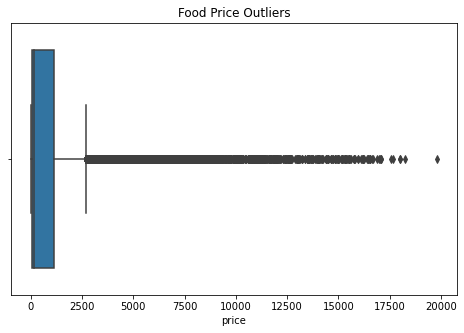

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x=food_df['price'])

plt.title("Food Price Outliers")
plt.show()

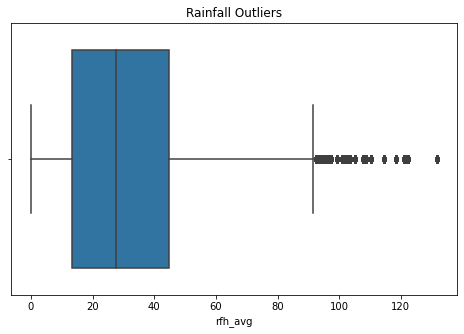

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x=rainfall_df['rfh_avg'])

plt.title("Rainfall Outliers")
plt.show()

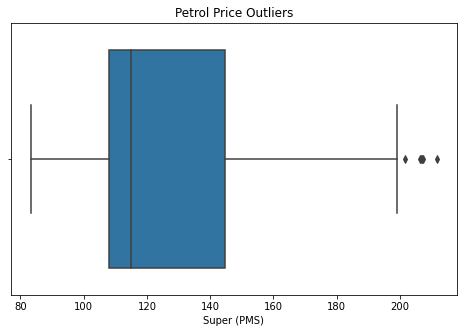

In [62]:
plt.figure(figsize=(8,5))
sns.boxplot(x=fuel_df['Super (PMS)'])

plt.title("Petrol Price Outliers")
plt.show()

### Detect Outliers Using IQR

In [64]:
Q1 = food_df['price'].quantile(0.25)
Q3 = food_df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

food_df = food_df[
    (food_df['price'] >= lower) &
    (food_df['price'] <= upper)
]

# Merge Datasets

The datasets are merged to combine food prices, rainfall information, and fuel prices into a single analytical dataset.

The merge is performed using common time-related features such as year and month.

In [76]:
# Convert to datetime
food_df['date'] = pd.to_datetime(food_df['date'])
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])
fuel_df['Date'] = pd.to_datetime(fuel_df['Date'])

In [77]:
# Create year and month columns
food_df['year'] = food_df['date'].dt.year
food_df['month'] = food_df['date'].dt.month

rainfall_df['year'] = rainfall_df['date'].dt.year
rainfall_df['month'] = rainfall_df['date'].dt.month

fuel_df['year'] = fuel_df['Date'].dt.year
fuel_df['month'] = fuel_df['Date'].dt.month

In [ ]:
# # Rename important columns
# rainfall_df.rename(columns={
#     'rfh_avg': 'rainfall_avg'
# }, inplace=True)

# fuel_df.rename(columns={
#     'Super (PMS)': 'petrol_price',
#     'Diesel (AGO)': 'diesel_price',
#     'Kerosene (IK)': 'kerosene_price'
# }, inplace=True)

In [78]:
# Merge food and fuel datasets
merged_df = pd.merge(
    food_df,
    fuel_df,
    on=['year', 'month'],
    how='left'
)

In [79]:
# Merge rainfall dataset
merged_df = pd.merge(
    merged_df,
    rainfall_df,
    on=['year', 'month'],
    how='left'
)

In [80]:
# Preview merged dataset
merged_df.head()

,date_x,admin1,admin2,market,category,commodity,unit,price,year,month,...,PCODE,rfh,rainfall_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q
0,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize,KG,16.13,2006,1,...,KE019,5.953162,15.759407,20.501171,66.389694,183.901640,346.43607,52.762400,35.721080,53.751354
1,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize,KG,16.13,2006,1,...,KE019,8.496487,19.294770,20.716627,62.209213,160.978930,328.69415,55.553055,38.263546,49.739838
2,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize,KG,16.13,2006,1,...,KE019,8.517565,16.265417,22.967213,51.319595,132.058550,292.37277,63.565952,49.658050,46.089810
3,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize,KG,16.13,2006,1,...,KE004,2.349981,7.491129,11.327618,59.550900,111.472984,261.05520,58.841610,25.294172,43.777752
4,2006-01-15,Coast,Mombasa,Mombasa,cereals and tubers,Maize,KG,16.13,2006,1,...,KE004,2.986582,6.561026,9.603429,37.986458,107.913160,251.00100,69.081950,33.972160,44.106530


In [81]:
# Check dataset shape
merged_df.shape

(3151710, 28)

# Exploratory Data Analysis (EDA)

## 1. Food Price Trend Over Time

This visualization shows how food prices have changed over time across the dataset.

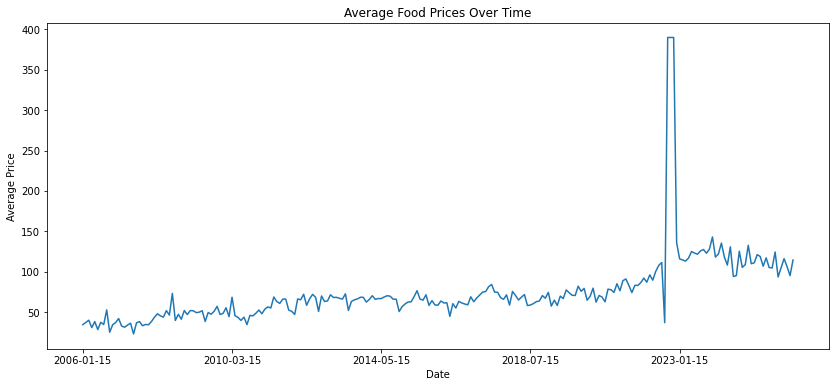

In [66]:
plt.figure(figsize=(14,6))

monthly_prices = food_df.groupby('date')['price'].mean()

monthly_prices.plot()

plt.title("Average Food Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")

plt.show()

## 2. Average Prices by Commodity

This analysis compares the average prices of different commodities.

In [87]:
important_commodities = [
    'Maize',
    'Beans',
    'Milk (cow, pasteurized)'
]

filtered_df = food_df[
    food_df['commodity'].isin(important_commodities)
]

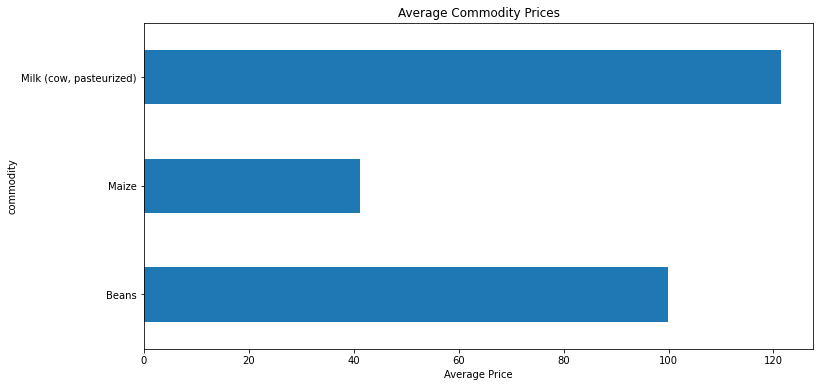

In [88]:
plt.figure(figsize=(12,6))

commodity_avg = filtered_df.groupby('commodity')['price'].mean()

commodity_avg.plot(kind='barh')

plt.title("Average Commodity Prices")
plt.xlabel("Average Price")

plt.show()

## 3. Relationship Between Rainfall and Food Prices

This visualization examines the relationship between rainfall levels and food prices.

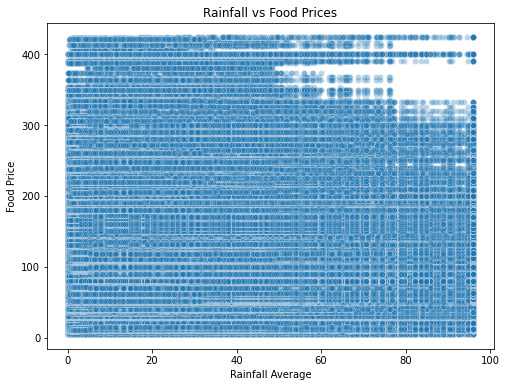

In [90]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=merged_df['rainfall_avg'],
    y=merged_df['price'],
     alpha=0.3
)

plt.title("Rainfall vs Food Prices")

plt.xlabel("Rainfall Average")

plt.ylabel("Food Price")

plt.show()

## 4. Fuel Prices vs Food Prices

This analysis investigates how fuel prices influence food commodity prices.

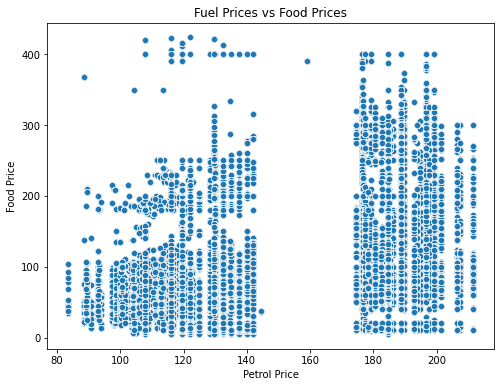

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=merged_df['petrol_price'],
    y=merged_df['price']
)

plt.title("Fuel Prices vs Food Prices")

plt.xlabel("Petrol Price")

plt.ylabel("Food Price")

plt.show()

## 5. Correlation Analysis

The correlation heatmap is used to identify relationships between numerical variables.

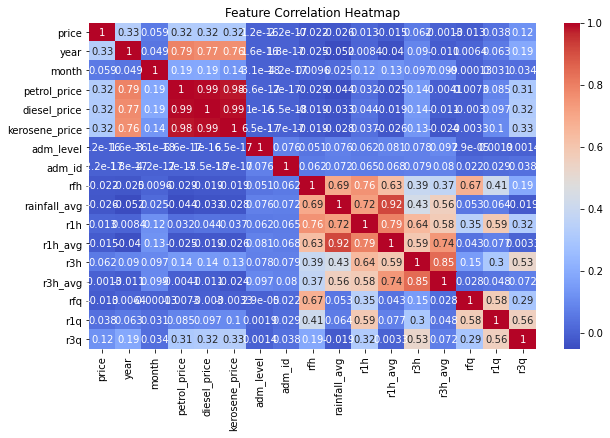

In [86]:
plt.figure(figsize=(10,6))

numeric_df = merged_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

## 6.Seasonal Price Analysis

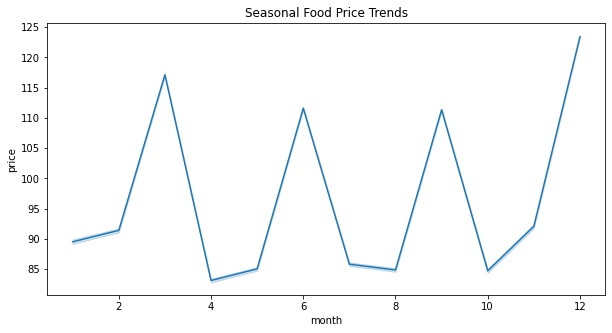

In [89]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x='month',
    y='price',
    data=merged_df
)

plt.title("Seasonal Food Price Trends")

plt.show()

# Key Insights from EDA

The exploratory analysis revealed several important findings:

- Food prices generally increased over time
- Certain commodities consistently showed higher prices
- Rainfall patterns may influence food prices
- Fuel prices appear to affect commodity pricing
- Strong correlations exist between fuel-related variables
- Seasonal patterns are visible in commodity pricing trends

These insights support the use of machine learning models for food price forecasting.

# Modelling🤖🚀

In [91]:
import statsmodels.api as sm
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,plot_roc_curve,auc,classification_report
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LogisticRegression

## Pre-process data  
Split into train and test data  
Standardise the numeric columns  
Perfom one hot encoding   


## 1.Split into train and test data
